In [1]:
import os
import numpy as np
import pandas as pd
import ast
import time
import tracemalloc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from sklearn.metrics import precision_score, recall_score, f1_score
import shap
import warnings
warnings.filterwarnings('ignore') # Hides annoying SHAP warnings

# --- Sanity Check for ALL files ---
# 1. Check if the master label file exists
if not os.path.exists('labeled_anomalies.csv'):
    print("❌ Error: 'labeled_anomalies.csv' is missing. Check your root folder.")
else:
    # 2. Read the CSV to get the list of all expected channels
    labels_df = pd.read_csv('labeled_anomalies.csv')
    channels = labels_df['chan_id'].unique()
    
    missing_files = []
    
    # 3. Check train and test folders for every single channel listed in the CSV
    for chan in channels:
        # Note: Using 'data/data/' based on your previous code snippet
        train_path = f'data/data/train/{chan}.npy'
        test_path = f'data/data/test/{chan}.npy'
        
        if not os.path.exists(train_path):
            missing_files.append(train_path)
        if not os.path.exists(test_path):
            missing_files.append(test_path)
            
    # 4. Final Verification
    if len(missing_files) == 0:
        print(f"Success: Labels and all {len(channels)} channels (train & test data) found! Environment is ready.")
    else:
        print(f"❌ Error: Missing {len(missing_files)} files.")
        print(f"For example, couldn't find: {missing_files[:3]}") # Prints the first 3 missing files so you know where to look

Success: Labels and all 81 channels (train & test data) found! Environment is ready.


C:\Users\tdpmh\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- CONFIG ---
channel = 'P-1' 

print(f"Loading telemetry for channel: {channel}...")
X_train = np.load(f'data/data/train/{channel}.npy')
X_test = np.load(f'data/data/test/{channel}.npy')

# --- PARSE LABELS ---
labels_df = pd.read_csv('labeled_anomalies.csv')
channel_info = labels_df[labels_df['chan_id'] == channel].iloc[0]
anomaly_sequences = ast.literal_eval(channel_info['anomaly_sequences'])

# Create ground truth array
y_test = np.zeros(len(X_test))
for seq in anomaly_sequences:
    start, end = seq
    y_test[start:end] = 1

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Loading telemetry for channel: P-1...
Training data shape: (2872, 25)
Testing data shape: (8505, 25)


In [3]:
# --- Z-SCORE BASELINE ---
import time
import tracemalloc

print("Running Z-Score Baseline...")
start_time_z = time.time()
tracemalloc.start()

# 1. Calculate Z-scores, adding 1e-8 to prevent division-by-zero on flat features
z_scores = np.abs((X_test - np.mean(X_train, axis=0)) / (np.std(X_train, axis=0) + 1e-8))

# 2. Get the maximum Z-score across all features for each timestep
max_z_scores = np.max(z_scores, axis=1)

# 3. Apply a realistic threshold 
z_threshold = 2.0 
z_preds = (max_z_scores > z_threshold).astype(int)

# --- Stop tracking time and RAM ---
_, z_ram_bytes = tracemalloc.get_traced_memory()
tracemalloc.stop()

z_time = (time.time() - start_time_z) * 1000 # Convert to milliseconds
z_ram = z_ram_bytes / (1024 * 1024) # Convert to MB

# 4. Calculate metrics
z_precision = precision_score(y_test, z_preds, zero_division=0)
z_recall = recall_score(y_test, z_preds, zero_division=0)
z_f1 = f1_score(y_test, z_preds, zero_division=0)

print(f"Z-Score Metrics (Threshold {z_threshold}): Precision: {z_precision:.4f}, Recall: {z_recall:.4f}, F1: {z_f1:.4f}")

Running Z-Score Baseline...
Z-Score Metrics (Threshold 2.0): Precision: 0.0924, Recall: 0.1925, F1: 0.1248


In [4]:
# Prepare sequences (lookback of 50 timesteps to capture context)
def to_sequences(data, seq_size=50):
    x = []
    for i in range(len(data) - seq_size):
        x.append(data[i:(i + seq_size)])
    return np.array(x)

X_train_seq = to_sequences(X_train)
X_test_seq = to_sequences(X_test)
y_test_seq = y_test[50:] # Match label length to sequence length

print("Building and training LSTM Autoencoder...")
model = Sequential([
    LSTM(64, activation='relu', input_shape=(50, X_train.shape[1]), return_sequences=False),
    RepeatVector(50),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(X_train.shape[1]))
])

model.compile(optimizer='adam', loss='mse')
# Training the model
model.fit(X_train_seq, X_train_seq, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

# Inference (Testing)
print("Running LSTM Inference...")
start_time = time.time()
tracemalloc.start()

reconstructed = model.predict(X_test_seq)
mse = np.mean(np.power(X_test_seq - reconstructed, 2), axis=(1,2))

# Dynamic thresholding: flag top 5% highest errors as anomalies
threshold_lstm = np.percentile(mse, 95) 
lstm_preds = (mse > threshold_lstm).astype(int)

_, peak_ram_lstm = tracemalloc.get_traced_memory()
tracemalloc.stop()
lstm_time = (time.time() - start_time) * 1000
print("LSTM complete.")

Building and training LSTM Autoencoder...
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0270 - val_loss: 0.0299
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0241 - val_loss: 0.0291
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0231 - val_loss: 0.0286
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0219 - val_loss: 0.0273
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0196 - val_loss: 0.0254
Running LSTM Inference...
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
LSTM complete.


Running SHAP explainability on the top 3 most severe anomalies...
Top 3 anomaly timesteps: [6295  712 2790]
Calculating SHAP values (this may take a minute with KernelExplainer)...


100%|██████████| 3/3 [02:39<00:00, 53.22s/it]


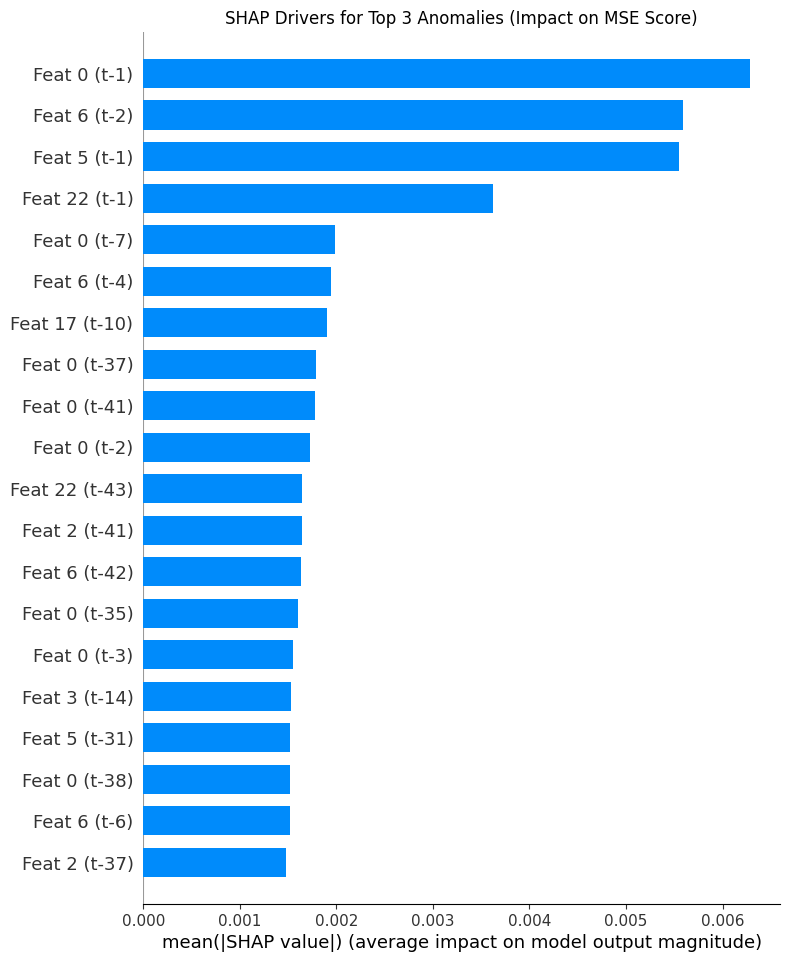

In [5]:
# --- EXTENDED SHAP ANALYSIS ---
print("Running SHAP explainability on the top 3 most severe anomalies...")

# 1. Find the indices of the top 3 highest reconstruction errors (MSE)
top_3_indices = np.argsort(mse)[-3:][::-1]
print(f"Top 3 anomaly timesteps: {top_3_indices}")

# Extract the 3D samples from the TEST SEQUENCES (Fixed)
top_3_samples = X_test_seq[top_3_indices]

# --- THE FIX FOR 3D LSTMs ---
# SHAP DeepExplainer struggles with 3D Autoencoder outputs. 
# We use KernelExplainer to directly explain the actual Anomaly Score (the MSE).

# Use the 3D sequence array for shapes (Fixed)
seq_len = X_train_seq.shape[1]
num_features = X_train_seq.shape[2]

# Flatten data to 2D for SHAP compatibility
background_2d = X_train_seq[:50].reshape(50, -1) # 50 background samples keeps it fast
top_3_2d = top_3_samples.reshape(3, -1)

# Wrapper function: takes 2D data, reshapes to 3D, gets model prediction, returns MSE
def calculate_mse_anomaly_score(x_2d):
    x_3d = x_2d.reshape(-1, seq_len, num_features)
    preds = model.predict(x_3d, verbose=0)
    # Return the Mean Squared Error per sample
    return np.mean(np.square(x_3d - preds), axis=(1, 2))

# 2. Initialize KernelExplainer 
print("Calculating SHAP values (this may take a minute with KernelExplainer)...")
explainer = shap.KernelExplainer(calculate_mse_anomaly_score, background_2d)

# 3. Generate SHAP values
shap_values = explainer.shap_values(top_3_2d)

# Generate clean feature names for the plot (e.g., "Feat 0 (t-10)")
feature_names = [f'Feat {f} (t-{seq_len-t})' for t in range(seq_len) for f in range(num_features)]

# 4. Plot Summary Plot
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values, 
    top_3_2d, 
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Drivers for Top 3 Anomalies (Impact on MSE Score)")
plt.show()

In [6]:
# Calculate total sequences for per-sequence latency
num_seq = len(X_test_seq)

results = pd.DataFrame({
    "Method": ["Z-Score", "LSTM AE"],
    "Precision": [precision_score(y_test, z_preds, zero_division=0), precision_score(y_test_seq, lstm_preds, zero_division=0)],
    "Recall": [recall_score(y_test, z_preds, zero_division=0), recall_score(y_test_seq, lstm_preds, zero_division=0)],
    "F1 Score": [f1_score(y_test, z_preds, zero_division=0), f1_score(y_test_seq, lstm_preds, zero_division=0)],
    "Inf Time/Seq (ms)": [z_time/len(X_test), lstm_time/num_seq],
    "Peak RAM (MB)": [z_ram, peak_ram_lstm/(1024*1024)]
})

# Display the clean table
display(results)

,Method,Precision,Recall,F1 Score,Inf Time/Seq (ms),Peak RAM (MB)
0,Z-Score,0.092367,0.192513,0.124837,0.000360,3.311084
1,LSTM AE,0.078014,0.044118,0.056362,0.473465,203.556630


The Z-score baseline doesn't perform very well. It hsa very low precision and recall, indicating it struggles to capture complex temporal patterns in the telemetry and produces both false positives and missed anomalies. The LSTM autoencode improves performance slightly, achieving higher precision, recall and F1 score. This suggests that is it better at modeling sequentiall dependencies and subtle deviations in the data. However, it has a much higher inference time and memeory usage, making it less suitable for strict real-time or resoruce-constrained environments. The Z-score tends to catch larger, more obvious deviations while missing the smaller anomaleis. On the other hand, the LSTM can detect the more subtle anomalies but still lacks strong overall accuracy. Overall, there is a trade-off between the simplicity and efficiency of the Z-score and the modeling power of the LSTM autoencoder. 